<a href="https://colab.research.google.com/github/mafudsetiono/Hotel-Analytics/blob/main/Hotel_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import Library
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.ticker as ticker
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

#Load & Overview

In [ ]:
df = pd.read_csv("train.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,bookingID
0,"Crystal Cove, Barbados Barbados",0,8,2019,January,2,10,0,4,2,...,314.0,NaN,0,Transient,38.40,0,0,Check-Out,2019-01-14,1
1,"Greensboro Courtyard Greensboro, NC",1,524,2018,December,51,15,0,2,2,...,1.0,NaN,0,Transient,62.80,0,0,Canceled,2017-10-21,2
2,"The Westin Peachtree Plaza, Atlanta Atlanta, GA",1,175,2019,May,20,19,1,2,2,...,12.0,NaN,0,Transient,110.00,0,0,Canceled,2018-11-25,3
3,Courtyard by Marriott Aberdeen Airport Aberdee...,0,0,2018,October,43,17,1,0,1,...,NaN,200.0,0,Transient,45.00,0,0,Check-Out,2018-10-18,4
4,"W New York – Union Square New York, NY",1,33,2017,September,39,26,2,3,2,...,16.0,NaN,0,Transient,57.92,0,1,Canceled,2017-08-24,5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83293 entries, 0 to 83292
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           83293 non-null  object 
 1   is_canceled                     83293 non-null  int64  
 2   lead_time                       83293 non-null  int64  
 3   arrival_date_year               83293 non-null  int64  
 4   arrival_date_month              83293 non-null  object 
 5   arrival_date_week_number        83293 non-null  int64  
 6   arrival_date_day_of_month       83293 non-null  int64  
 7   stays_in_weekend_nights         83293 non-null  int64  
 8   stays_in_week_nights            83293 non-null  int64  
 9   adults                          83293 non-null  int64  
 10  children                        83290 non-null  float64
 11  babies                          83293 non-null  int64  
 12  meal                            

In [ ]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,bookingID
count,83293.000000,83293.000000,83293.000000,83293.000000,83293.000000,83293.000000,83293.000000,83293.000000,83290.000000,83293.000000,...,83293.000000,83293.000000,83293.000000,71889.000000,4734.000000,83293.000000,83293.000000,83293.000000,83293.000000,83293.000000
mean,0.369503,103.914230,2018.156808,27.164023,15.786116,0.930390,2.503812,1.854466,0.103614,0.008032,...,0.086994,0.141765,0.223068,86.867282,190.003802,2.352238,101.724373,0.061818,0.571945,41647.000000
std,0.482673,106.874124,0.706656,13.623752,8.775931,1.004196,1.924511,0.606139,0.398821,0.100641,...,0.862988,1.554390,0.656237,110.875605,131.969152,17.820652,48.082552,0.245027,0.793742,24044.762323
min,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,18.000000,2018.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.530000,0.000000,0.000000,20824.000000
50%,0.000000,69.000000,2018.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,14.000000,183.000000,0.000000,94.500000,0.000000,0.000000,41647.000000
75%,1.000000,160.000000,2019.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000,62470.000000
max,1.000000,737.000000,2019.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,...,26.000000,70.000000,21.000000,535.000000,543.000000,391.000000,508.000000,8.000000,5.000000,83293.000000


In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
company,78559
agent,11404
country,346
children,3
hotel,0
arrival_date_week_number,0
arrival_date_day_of_month,0
is_canceled,0
lead_time,0
stays_in_week_nights,0


In [ ]:
df.duplicated().sum()

np.int64(0)

#Insight
Dataset terdiri dari 83.293 Rows dan 33 kolom
Tipe:
  

*   Numerik: 21 (Int + Float)
*   Kategorikal: 12

company missing sekitar 90% yang artinya hampir useless untuk analisis, di DROP tidak akan mengubah hasil analisis

agent missing sekitar 12%, ini cukup tricky karena bisa penting untuk untuk channel booking, tapi missing cukup banyak, jadi cukup isi dengan "No Agent" saja, jangan di drop.

country hanya 346 missing, masih aman untuk diisi "Unknown"

children (3) isi dengan median saja

Duplikat = 0. ini cukup bagus karena tidak ada masalah




#Data Cleaning

In [ ]:
# DROP
df.drop(columns=['company'], inplace=True)

# HANDLE MISSING
df['agent'] = df['agent'].fillna(0)
df['country'] = df['country'].fillna('Unknown')
df['children'] = df['children'].fillna(0)

# DATE
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

# FEATURE ENGINEERING
df['total_guests'] = df['adults'] + df['children'] + df['babies']
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['total_revenue'] = df['adr'] * df['total_stay']
df['realized_revenue'] = df.apply(
    lambda x: x['total_revenue'] if x['is_canceled'] == 0 else 0,
    axis=1
)
df['revenue_loss'] = df.apply(
    lambda x: x['total_revenue'] if x['is_canceled'] == 1 else 0,
    axis=1
)

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


#Cek Outlier
Outlier saya evaluasi berdasarkan konteks bisnis, tidak semua saya hapus karena bisa merepresentasikan behavior nyata customer.


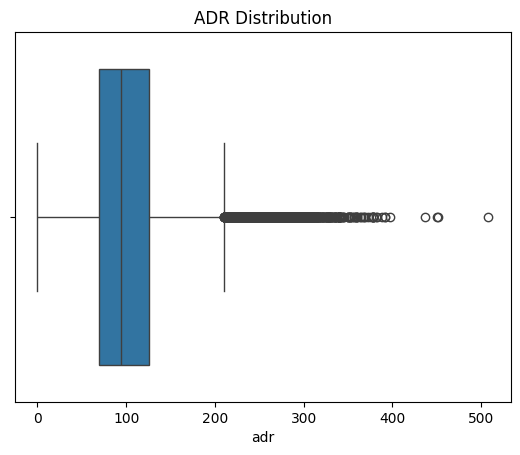

In [ ]:
#ADR
sns.boxplot(x=df['adr'])
plt.title('ADR Distribution')
plt.show()

In [ ]:
df = df[df['adr'] > 0]

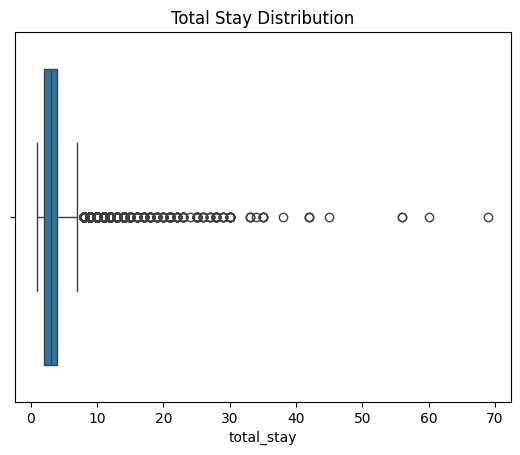

In [ ]:
#TOTAL STAY
sns.boxplot(x=df['total_stay'])
plt.title('Total Stay Distribution')
plt.show()

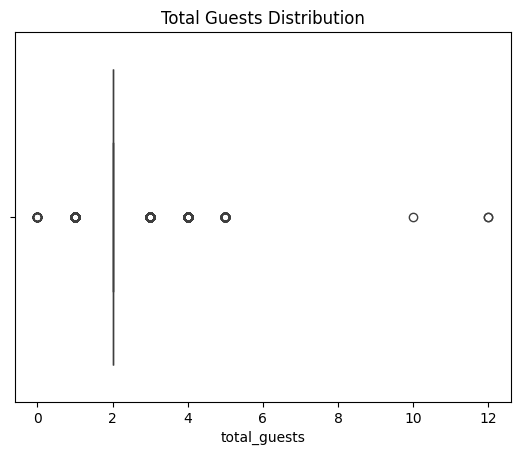

In [ ]:
#TOTAL GUEST
sns.boxplot(x=df['total_guests'])
plt.title('Total Guests Distribution')
plt.show()

In [ ]:
df = df[df['total_guests'] <= 10]

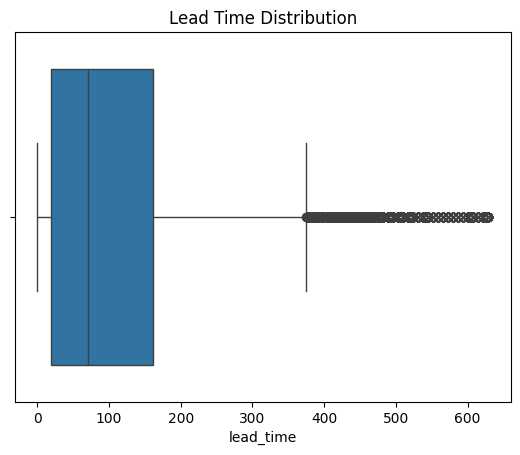

In [ ]:
#LEAD TIME
sns.boxplot(x=df['lead_time'])
plt.title('Lead Time Distribution')
plt.show()

Saya mengevaluasi outlier berdasarkan konteks bisnis, bukan langsung menghapus secara statistik.

Beberapa variabel seperti ADR, total stay, dan lead time masih masuk akal secara bisnis sehingga saya pertahankan.

Namun pada total_guests, terdapat nilai ekstrem yang kurang realistis untuk satu booking, sehingga saya melakukan filtering untuk menjaga kualitas analisis.

#Cancellation Analysis (EDA)
Goal = Mengidentifikasi faktor utama yang mendorong pembatalan dan dampaknya ke revenue


##Overall Cancellation Rate

In [ ]:
cancel_rate = df['is_canceled'].mean() * 100
cancel_rate

np.float64(37.408886121387496)

##Cancellation by Lead Time

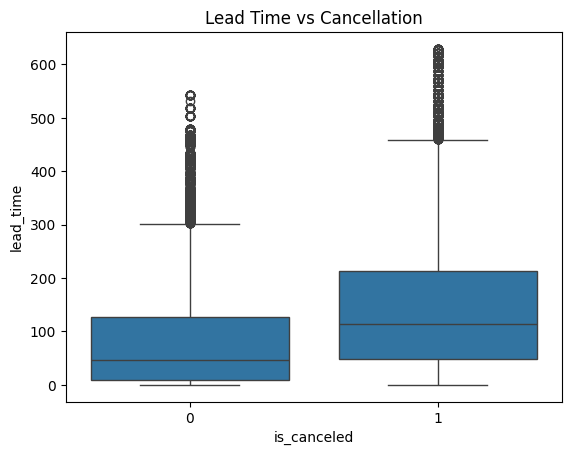

In [ ]:
sns.boxplot(data=df, x='is_canceled', y='lead_time')
plt.title('Lead Time vs Cancellation')
plt.show()

##Deposit Type


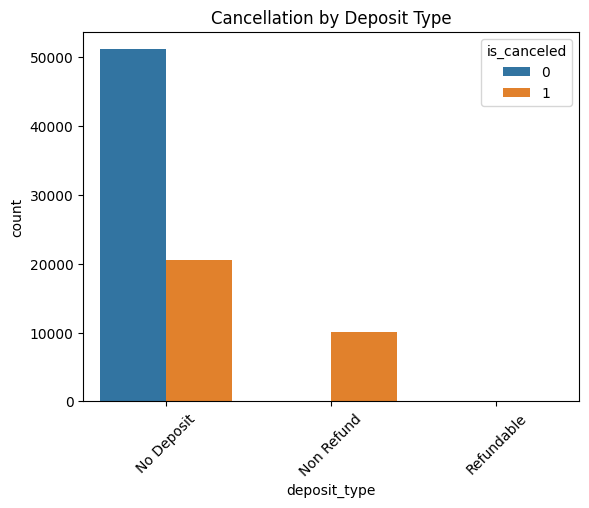

In [ ]:
sns.countplot(data=df, x='deposit_type', hue='is_canceled')
plt.title('Cancellation by Deposit Type')
plt.xticks(rotation=45)
plt.show()

##Customer Type

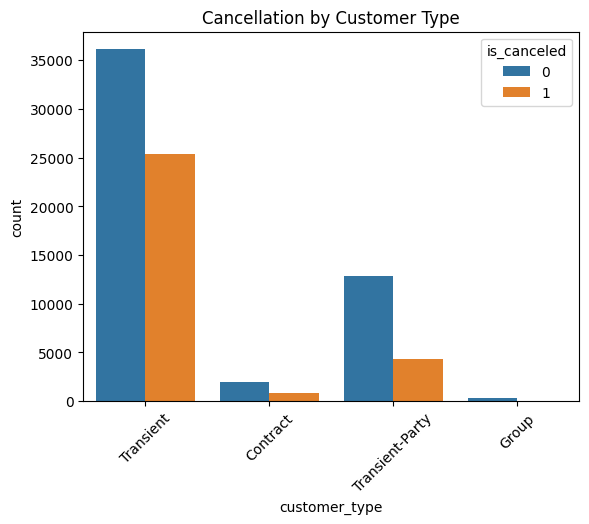

In [ ]:
sns.countplot(data=df, x='customer_type', hue='is_canceled')
plt.title('Cancellation by Customer Type')
plt.xticks(rotation=45)
plt.show()

##Previous Cancellation Behavior

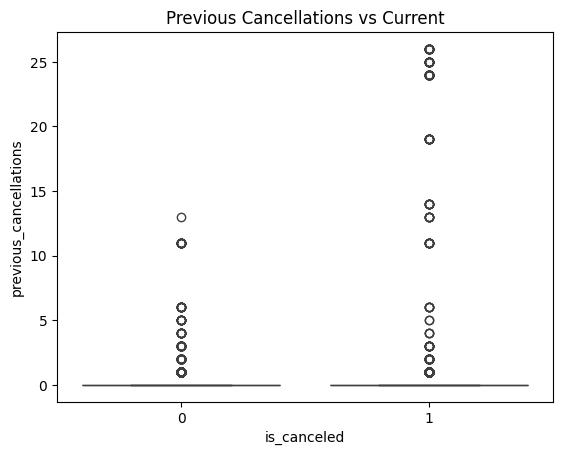

In [ ]:
sns.boxplot(data=df, x='is_canceled', y='previous_cancellations')
plt.title('Previous Cancellations vs Current')
plt.show()

##Market Segment

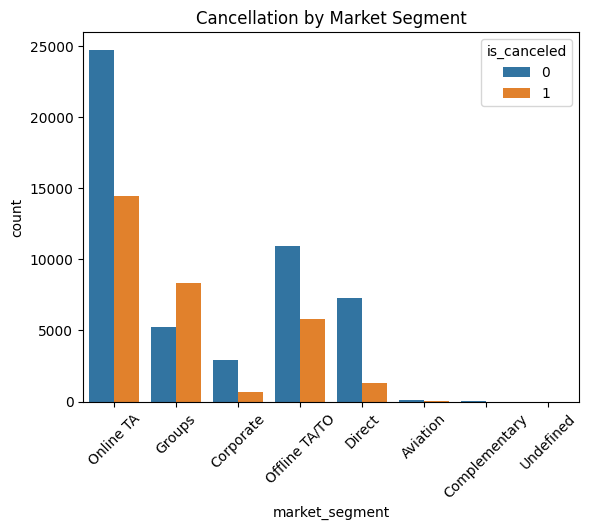

In [ ]:
sns.countplot(data=df, x='market_segment', hue='is_canceled')
plt.xticks(rotation=45)
plt.title('Cancellation by Market Segment')
plt.show()

##Revenue Impact

In [ ]:
cancel_revenue = df[df['is_canceled'] == 1]['total_revenue'].sum()
total_revenue = df['total_revenue'].sum()

loss_percentage = (cancel_revenue / total_revenue) * 100

cancel_revenue, loss_percentage

(np.float64(11655104.96), np.float64(39.06326451543525))

##Insight
Cancellation dipengaruhi oleh lead time, deposit policy, dan tipe customer.
Booking dengan lead time panjang, tanpa deposit, dan dari customer transient memiliki risiko pembatalan tertinggi.

Hal ini menyebabkan kehilangan potensi revenue hingga ~39%.

#Booking Trend & Seasonality
Goal = Memahami pola waktu. Kapan demand tinggi, kapan rendah, dan bagaimana perilaku booking berubah sepanjang waktu

In [ ]:
month_map = {
    'January':1, 'February':2, 'March':3, 'April':4,
    'May':5, 'June':6, 'July':7, 'August':8,
    'September':9, 'October':10, 'November':11, 'December':12
}

df['month_num'] = df['arrival_date_month'].map(month_map)

df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['month_num'].astype(str) + '-' +
    df['arrival_date_day_of_month'].astype(str),
    errors='coerce'
)

In [ ]:
df[df['arrival_date'].isna()][
    ['arrival_date_year','arrival_date_month','arrival_date_day_of_month']
].head(10)

,arrival_date_year,arrival_date_month,arrival_date_day_of_month
1565,2018,February,29
3069,2018,February,29
3081,2018,February,29
3792,2018,February,29
4488,2018,February,29
5330,2018,February,29
5420,2018,February,29
5488,2018,February,29
6445,2018,February,29
7270,2018,February,29


In [ ]:
df['arrival_date'].isna().sum()

np.int64(65)

In [ ]:
df = df.dropna(subset=['arrival_date'])

Saya menemukan beberapa invalid date seperti 29 Februari pada tahun non kabisat, sehingga saya melakukan cleaning dengan menghapus data tersebut karena jumlahnya sangat kecil dan tidak signifikan terhadap analisis.

##Booking Trend Over Time

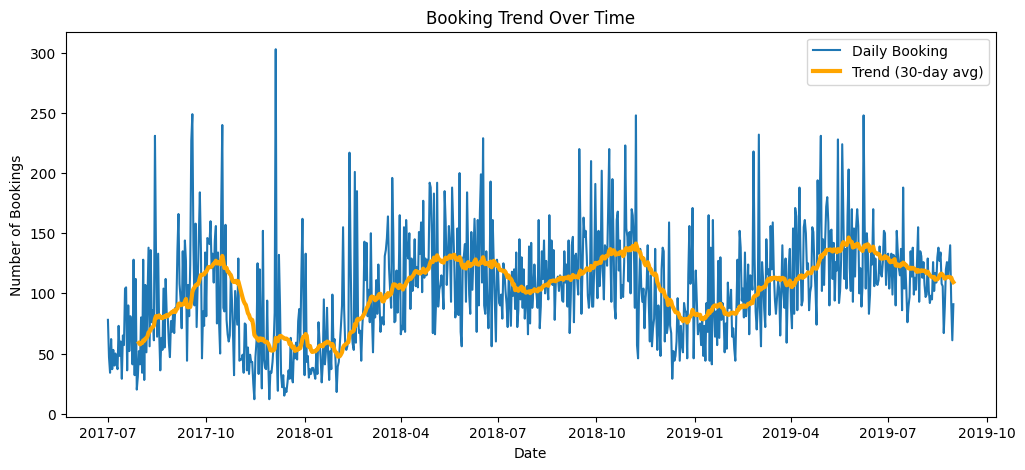

In [ ]:
booking_trend = df.groupby('arrival_date').size()

plt.figure(figsize=(12,5))
plt.plot(booking_trend, label='Daily Booking')

# rolling average (trendline)
rolling_mean = booking_trend.rolling(window=30).mean()
plt.plot(rolling_mean, color='orange', linewidth=3, label='Trend (30-day avg)')

plt.title('Booking Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Bookings')
plt.legend()
plt.show()

##Booking By Month

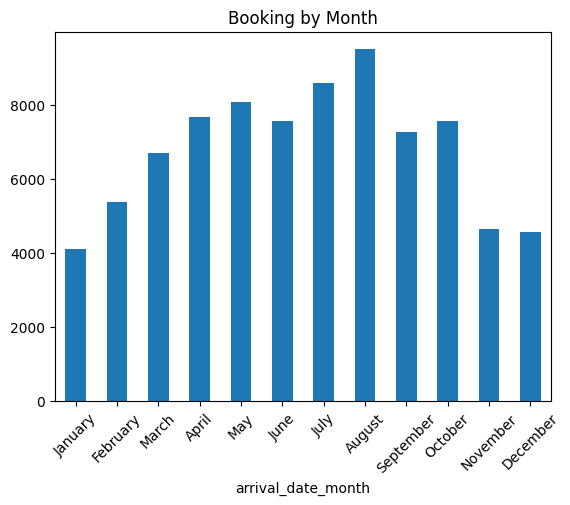

In [ ]:
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

monthly_booking = df.groupby('arrival_date_month').size().reindex(month_order)

monthly_booking.plot(kind='bar')
plt.title('Booking by Month')
plt.xticks(rotation=45)
plt.show()

##Cancellation By Month

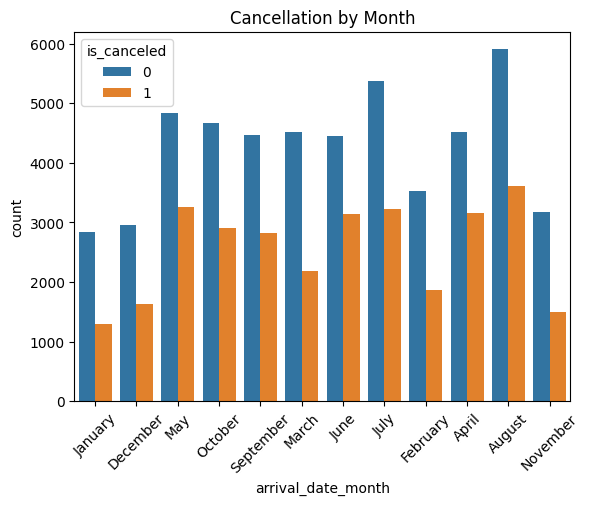

In [ ]:
sns.countplot(data=df, x='arrival_date_month', hue='is_canceled')
plt.xticks(rotation=45)
plt.title('Cancellation by Month')
plt.show()

##Week Number Analysis

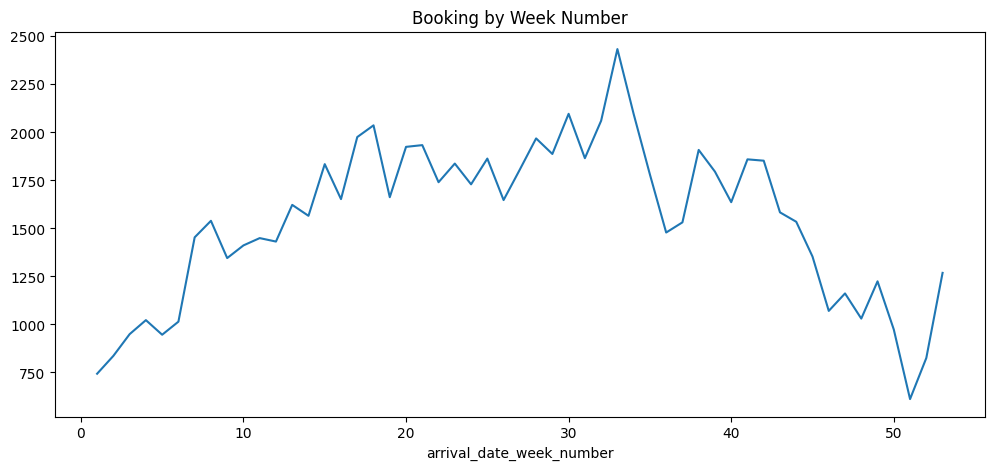

In [ ]:
weekly_booking = df.groupby('arrival_date_week_number').size()

weekly_booking.plot(figsize=(12,5))
plt.title('Booking by Week Number')
plt.show()

##ADR By Month (Revenue Seasonality)

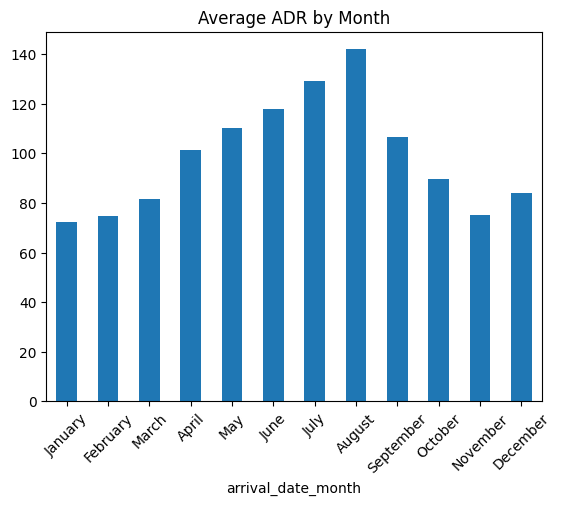

In [ ]:
monthly_adr = df.groupby('arrival_date_month')['adr'].mean().reindex(month_order)

monthly_adr.plot(kind='bar')
plt.title('Average ADR by Month')
plt.xticks(rotation=45)
plt.show()

##Insight
1. Booking Trend
Terlihat adanya fluktuasi harian yang cukup tinggi, namun trendline menunjukkan pola yang relatif stabil dengan beberapa periode peningkatan.
Hal ini mengindikasikan adanya pengaruh faktor musiman terhadap permintaan booking.

2. Monthly Seasonality
Permintaan tertinggi terjadi pada bulan Juli dan Agustus, yang mengindikasikan peak season (kemungkinan musim liburan).
Sedangkan bulan Januari dan Februari menunjukkan jumlah booking terendah (low season).

3. Cancellation Pattern
Tingkat pembatalan cenderung meningkat pada bulan dengan volume booking tinggi, seperti Juli dan Agustus.
Hal ini menunjukkan bahwa peak season tidak hanya meningkatkan demand, tetapi juga meningkatkan risiko pembatalan.

4. Weekly Pattern
Terlihat adanya peningkatan booking pada minggu ke-25 hingga ke-35, yang mengindikasikan periode mid-year peak.
Sebaliknya, penurunan signifikan terjadi pada akhir tahun (minggu ke-50 ke atas).

5. Revenue (ADR) Seasonality
ADR tertinggi terjadi pada bulan Agustus dan Juli, yang sejalan dengan peak demand.
Hal ini menunjukkan bahwa hotel telah menerapkan strategi dynamic pricing dengan menaikkan harga saat permintaan tinggi.

Terdapat korelasi antara peningkatan demand dan kenaikan harga (ADR), namun hal ini juga diikuti oleh peningkatan tingkat pembatalan.
Hal ini menunjukkan adanya trade-off antara revenue maximization dan booking stability.

#Revenue Optimization Analyisis
Goal = Menemukan cara meningkatkan revenue dari:
 - Pricing (ADR)
 - lama menginap
 - Segment Customer
 - risk (cancellation)

##Revenue By Customer Type

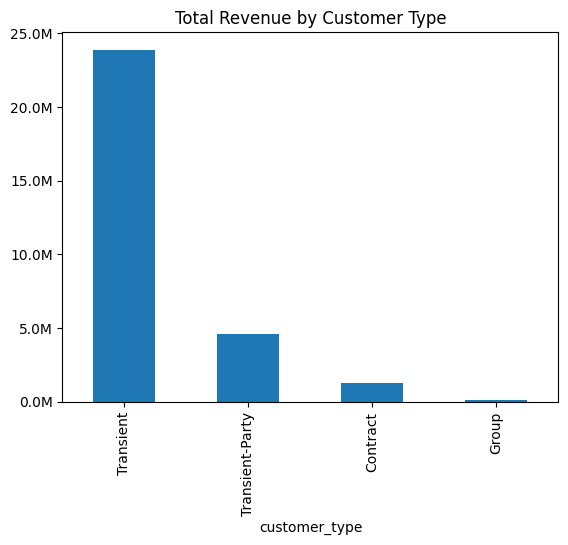

In [ ]:
def format_millions(x, pos):
    return f'{x*1e-6:.1f}M'

rev_customer = df.groupby('customer_type')['total_revenue'].sum().sort_values(ascending=False)
ax = rev_customer.plot(kind='bar')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_millions))
plt.title('Total Revenue by Customer Type')
plt.show()

##ADR vs Customer Type

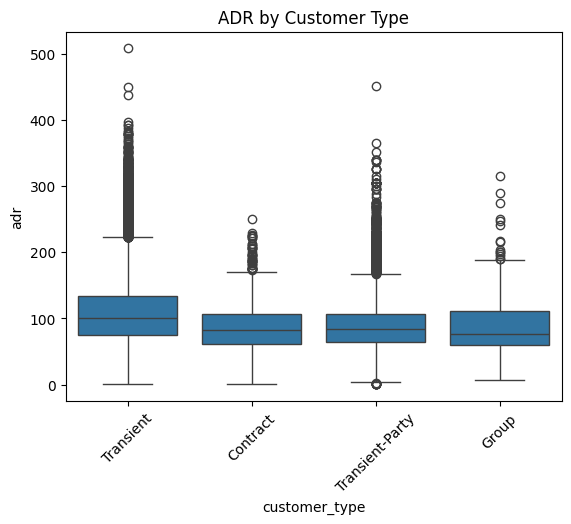

In [ ]:
sns.boxplot(data=df, x='customer_type', y='adr')
plt.xticks(rotation=45)
plt.title('ADR by Customer Type')
plt.show()

##Revenue By Market Segment

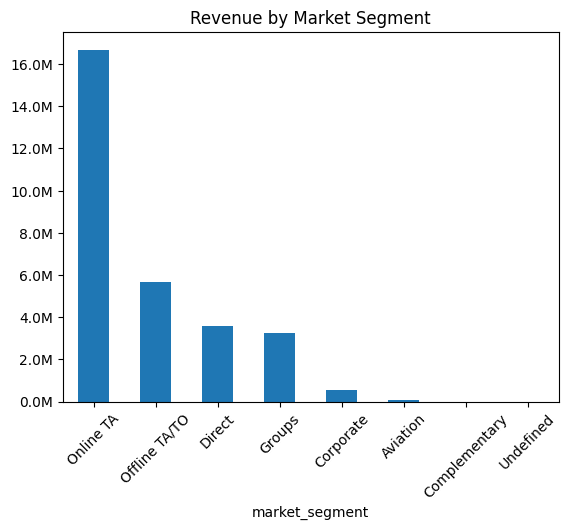

In [ ]:
rev_segment = df.groupby('market_segment')['total_revenue'].sum().sort_values(ascending=False)

ax = rev_segment.plot(kind='bar')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_millions))
plt.title('Revenue by Market Segment')
plt.xticks(rotation=45)
plt.show()

##Length of Stay vs Revenue

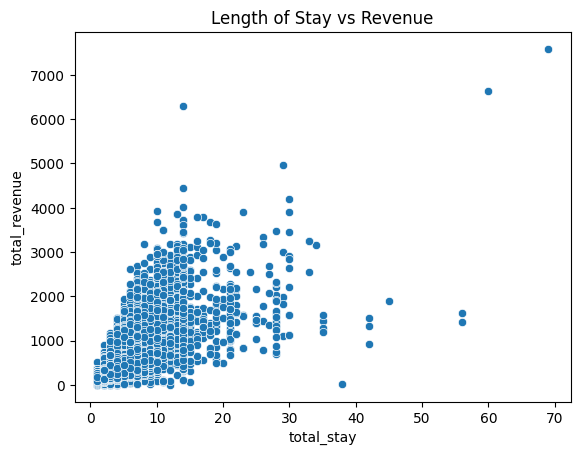

In [ ]:
sns.scatterplot(data=df, x='total_stay', y='total_revenue')
plt.title('Length of Stay vs Revenue')
plt.show()

##Revenue Loss By Segment

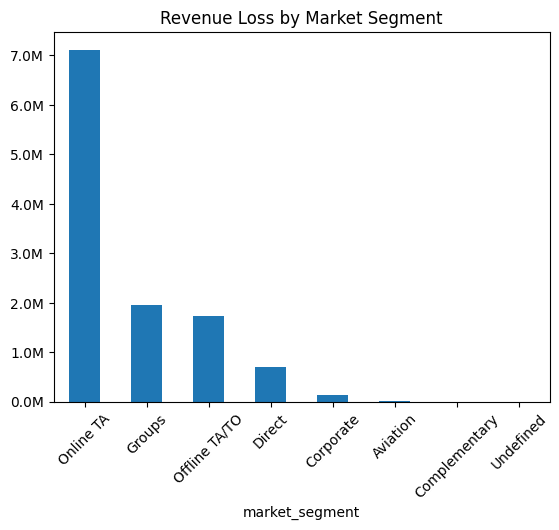

In [ ]:
loss_segment = df[df['is_canceled'] == 1].groupby('market_segment')['total_revenue'].sum().sort_values(ascending=False)

ax = loss_segment.plot(kind='bar')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_millions))
plt.title('Revenue Loss by Market Segment')
plt.xticks(rotation=45)
plt.show()

##ADR vs Cancellation

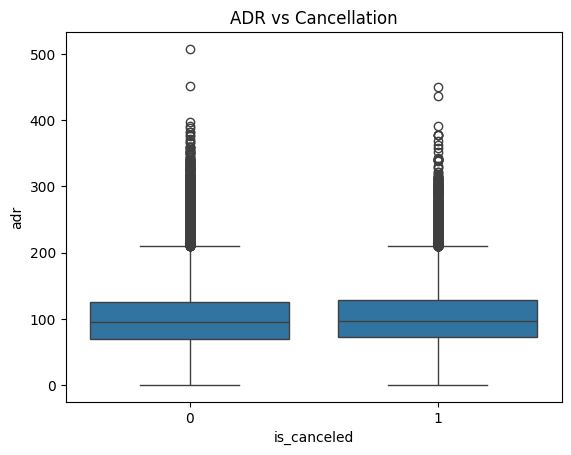

In [ ]:
sns.boxplot(data=df, x='is_canceled', y='adr')
plt.title('ADR vs Cancellation')
plt.show()


##Insight
1. Customer Contribution
Customer tipe Transient memberikan kontribusi revenue terbesar secara signifikan dibandingkan tipe lainnya.
Namun, tipe ini juga memiliki tingkat pembatalan yang tinggi, sehingga menjadi sumber revenue sekaligus risiko terbesar.

2. Pricing Behavior (ADR)
ADR tertinggi ditemukan pada customer Transient, yang menunjukkan bahwa customer individu cenderung bersedia membayar lebih tinggi dibandingkan corporate atau group.

3. Market Segment Performance
Segment Online Travel Agent (OTA) menjadi penyumbang revenue terbesar, namun juga menjadi kontributor utama terhadap revenue loss akibat pembatalan.
Hal ini menunjukkan trade-off antara volume tinggi dan risiko tinggi.

4. Length of Stay Impact
Terdapat korelasi positif antara lama menginap dan total revenue.
Semakin lama customer menginap, semakin tinggi revenue yang dihasilkan, meskipun terdapat beberapa outlier.

5. Revenue Loss Concentration
Sebagian besar kerugian revenue berasal dari segment Online TA dan Groups.
Hal ini menunjukkan bahwa strategi mitigasi pembatalan harus difokuskan pada segment tersebut.

6. ADR vs Cancellation
Tidak terdapat perbedaan signifikan antara ADR pada booking yang dibatalkan dan tidak.
Hal ini menunjukkan bahwa harga bukan faktor utama pembatalan, melainkan faktor lain seperti lead time dan deposit policy.

Terdapat trade-off antara volume dan kualitas booking.
Segment dengan volume tinggi seperti Online TA menghasilkan revenue besar, namun juga memiliki risiko pembatalan yang tinggi.
Sebaliknya, segment seperti corporate lebih stabil namun dengan kontribusi volume yang lebih kecil.

#Recommendation

1. Implement Dynamic Deposit Policy
Booking dengan lead time tinggi dan berasal dari segment berisiko (seperti Online TA dan Transient) sebaiknya dikenakan deposit atau non-refundable policy.
Hal ini bertujuan untuk meningkatkan komitmen customer dan mengurangi tingkat pembatalan.

2. Optimize High-Risk Channels (Online Travel Agent)
Meskipun OTA memberikan kontribusi revenue terbesar, segment ini juga memiliki tingkat pembatalan tertinggi.
Perusahaan dapat:
- Mengatur kebijakan deposit khusus untuk OTA
- Memberikan insentif untuk direct booking
- Melakukan segmentasi harga berdasarkan channel

3. Target High-Value & Stable Customers
Customer tipe Corporate dan Contract memiliki tingkat pembatalan yang lebih rendah.
Perusahaan dapat meningkatkan kerjasama dengan corporate client melalui:
- Paket khusus
- Kontrak jangka panjang
- Loyalty program

4. Leverage Peak Season with Risk Control
Pada periode peak season (Juli–Agustus), terjadi peningkatan demand sekaligus peningkatan pembatalan.
Strategi yang dapat diterapkan:
- Menaikkan harga (dynamic pricing)
- Menerapkan stricter cancellation policy
- Mengoptimalkan overbooking strategy secara terkontrol

5. Increase Length of Stay
Karena terdapat korelasi positif antara lama menginap dan revenue:
- Tawarkan diskon untuk extended stay
- Paket bundling (stay + layanan tambahan)
- Promosi khusus untuk long-stay customer

6. Customer Risk Profiling
Gunakan data historical seperti previous cancellations untuk mengidentifikasi customer berisiko tinggi.
Customer dengan riwayat pembatalan dapat:
- dikenakan kebijakan booking yang lebih ketat
- dibatasi fleksibilitasnya

7. Improve Booking Confirmation Strategy
Untuk booking dengan lead time panjang:
- Kirim reminder atau reconfirmation sebelum hari H
- Berikan insentif untuk memastikan booking tetap aktif

===========================================================================================================

#Data Preprocessing

In [ ]:
#Feature Engineering

#Lead Time Bin
df['lead_time_bin'] = pd.cut(
    df['lead_time'],
    bins=[-1, 7, 30, 90, 180, 365, 1000],
    labels=['Last Minute', 'Short', 'Medium', 'Long', 'Very Long', 'Extreme']
)

#Customer Value Segment
df['value_segment'] = pd.cut(
    df['adr'] * df['total_stay'],
    bins=[0, 100, 300, 700, 1500, 10000],
    labels=['Low', 'Medium', 'High', 'Very High', 'Luxury']
)

#Family Type
df['family_type'] = df.apply(
    lambda x: 'Family' if (x['children'] > 0 or x['babies'] > 0) else 'Non-Family',
    axis=1
)

#Total Stay Bin
df['stay_type'] = pd.cut(
    df['total_stay'],
    bins=[0, 2, 5, 10, 100],
    labels=['Short', 'Medium', 'Long', 'Very Long']
)

#Booking Risk Score
df['risk_score'] = (
    df['lead_time'] * 0.4 +
    df['previous_cancellations'] * 2 +
    (df['deposit_type'] == 'No Deposit').astype(int) * 5
)

df = df.drop(columns=[
    'lead_time',
])


In [ ]:
# Drop leakage & irrelevant columns
df_model = df.drop(columns=[
  'reservation_status',
  'reservation_status_date',
  'realized_revenue',
  'revenue_loss',
  'assigned_room_type',
  'total_revenue',
  'bookingID',
  'arrival_date_month',
  'arrival_date_week_number',
  'arrival_date_day_of_month',
  'stays_in_weekend_nights',
  'stays_in_week_nights',
  'total_guests',
  'arrival_date',
  'country',
  'agent'
])


Beberapa kolom dihapus untuk meningkatkan kualitas model serta menghindari data leakage.

Kolom seperti reservation_status, reservation_status_date, realized_revenue, dan revenue_loss dihapus karena mengandung informasi setelah proses booking selesai, sehingga dapat secara langsung merepresentasikan target dan menyebabkan model menjadi bias.

Selain itu, fitur seperti assigned_room_type juga dihapus karena ditentukan setelah proses booking berlangsung.

Kolom yang bersifat redundan seperti detail tanggal dan komponen lama menginap dihapus untuk mengurangi duplikasi informasi serta potensi multikolinearitas.

Sementara itu, fitur dengan jumlah kategori yang sangat banyak seperti country dan agent dihapus untuk menghindari noise dan meningkatkan kemampuan generalisasi model.

In [ ]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 81838 entries, 0 to 83292
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   hotel                           81838 non-null  object  
 1   is_canceled                     81838 non-null  int64   
 2   arrival_date_year               81838 non-null  int64   
 3   adults                          81838 non-null  int64   
 4   children                        81838 non-null  float64 
 5   babies                          81838 non-null  int64   
 6   meal                            81838 non-null  object  
 7   market_segment                  81838 non-null  object  
 8   distribution_channel            81838 non-null  object  
 9   is_repeated_guest               81838 non-null  int64   
 10  previous_cancellations          81838 non-null  int64   
 11  previous_bookings_not_canceled  81838 non-null  int64   
 12  reserved_room_type     

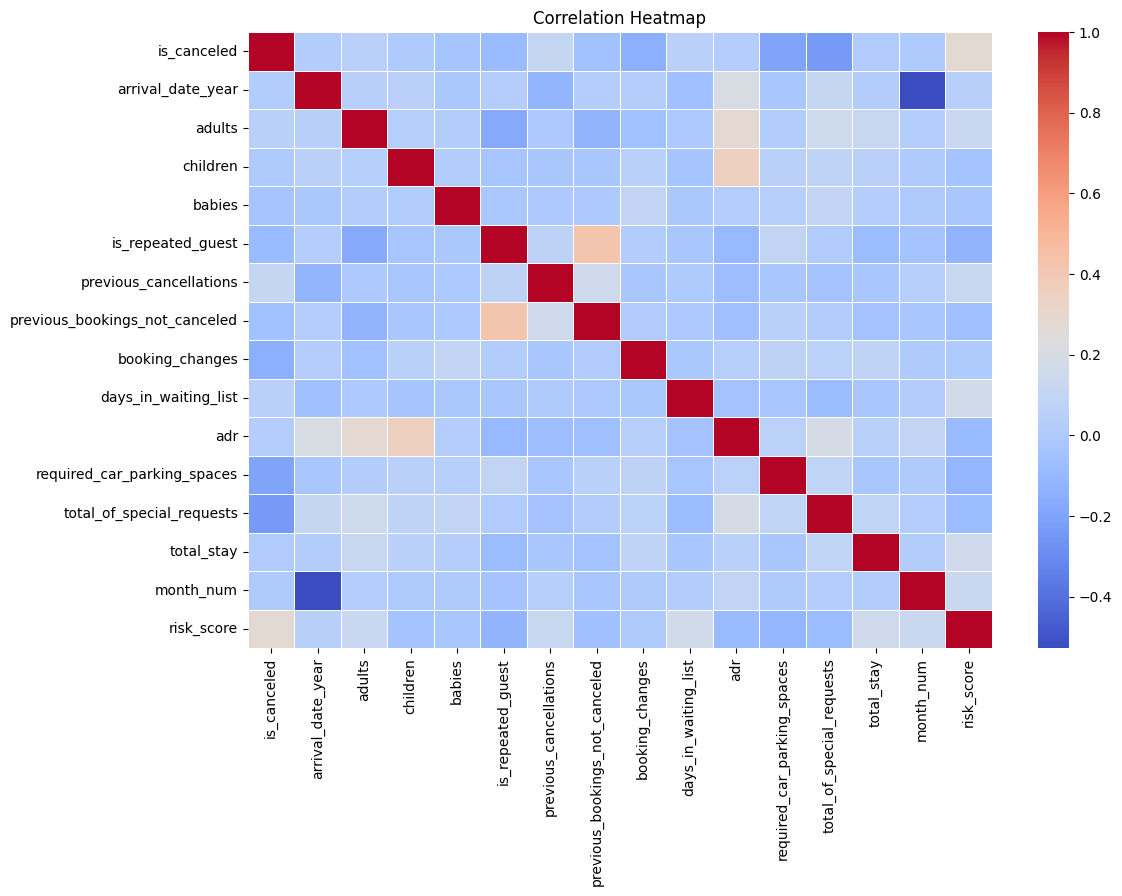

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# ambil hanya numeric
df_num = df_model.select_dtypes(include=['int64', 'float64'])

# correlation matrix
corr = df_num.corr()

# plot
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

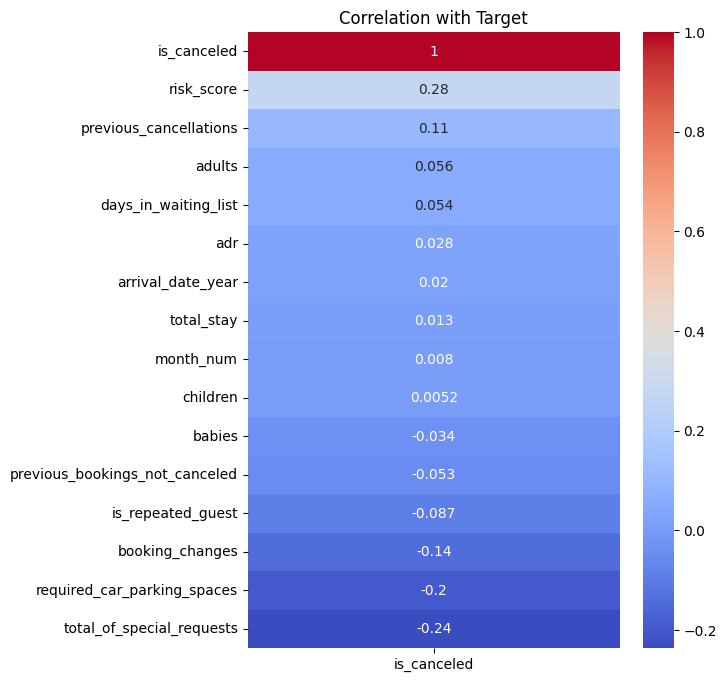

In [ ]:
corr_target = corr['is_canceled'].sort_values(ascending=False)

plt.figure(figsize=(6,8))
sns.heatmap(corr_target.to_frame(), annot=True, cmap='coolwarm')
plt.title("Correlation with Target")
plt.show()

**Heatmap**

Berdasarkan analisis korelasi, fitur yang memiliki hubungan positif paling kuat terhadap pembatalan adalah risk_score (0.28) dan previous_cancellations (0.11). Hal ini menunjukkan bahwa pelanggan dengan tingkat risiko tinggi serta riwayat pembatalan sebelumnya cenderung lebih berpotensi melakukan pembatalan.

Sementara itu, fitur seperti total_of_special_requests (-0.24) dan required_car_parking_spaces (-0.20) memiliki korelasi negatif, yang mengindikasikan bahwa pelanggan dengan kebutuhan khusus atau tingkat komitmen yang lebih tinggi cenderung memiliki kemungkinan pembatalan yang lebih rendah.

Secara keseluruhan, sebagian besar fitur memiliki nilai korelasi yang relatif rendah, yang menunjukkan bahwa perilaku pembatalan dipengaruhi oleh kombinasi berbagai faktor, bukan hanya satu variabel dominan.

#Split & Encode

In [ ]:
#Define Target & Features
X = df_model.drop('is_canceled', axis=1)
y = df_model['is_canceled']

In [ ]:
# Categorical & Numerical
cat_cols = X.select_dtypes(include=['object', 'category']).columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

print("Categorical:", list(cat_cols))
print("Numerical:", list(num_cols))

Categorical: ['hotel', 'meal', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'customer_type', 'lead_time_bin', 'value_segment', 'family_type', 'stay_type']
Numerical: ['arrival_date_year', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_stay', 'month_num', 'risk_score']


In [ ]:
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [86]:
X_train.shape, X_test.shape

((65470, 119), (16368, 119))

#Scaling

In [ ]:
#Scaling khusus logistic
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Modeling

##Logistic Regression

In [ ]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

# Predict
y_pred_log = log_model.predict(X_test_scaled)
y_proba_log = log_model.predict_proba(X_test_scaled)[:,1]

##Random Forest

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:,1]

##XGBoost

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:,1]

##Evaluation

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

def evaluate_model(name, y_true, y_pred, y_proba):
    print(f"\n{name}")
    print(classification_report(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_proba))

# Evaluate
evaluate_model("Logistic Regression", y_test, y_pred_log, y_proba_log)
evaluate_model("Random Forest", y_test, y_pred_rf, y_proba_rf)
evaluate_model("XGBoost", y_test, y_pred_xgb, y_proba_xgb)


Logistic Regression
              precision    recall  f1-score   support

           0       0.80      0.91      0.86     10246
           1       0.81      0.63      0.71      6122

    accuracy                           0.81     16368
   macro avg       0.81      0.77      0.78     16368
weighted avg       0.81      0.81      0.80     16368

ROC-AUC: 0.8611781982887736

Random Forest
              precision    recall  f1-score   support

           0       0.85      0.92      0.88     10246
           1       0.85      0.72      0.78      6122

    accuracy                           0.85     16368
   macro avg       0.85      0.82      0.83     16368
weighted avg       0.85      0.85      0.85     16368

ROC-AUC: 0.9163333785670926

XGBoost
              precision    recall  f1-score   support

           0       0.83      0.92      0.87     10246
           1       0.84      0.69      0.76      6122

    accuracy                           0.83     16368
   macro avg       0.83    

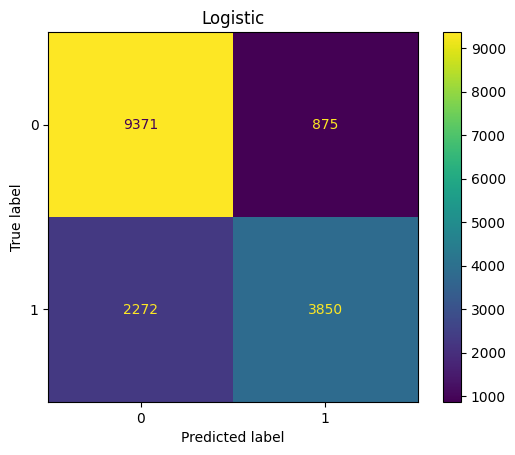

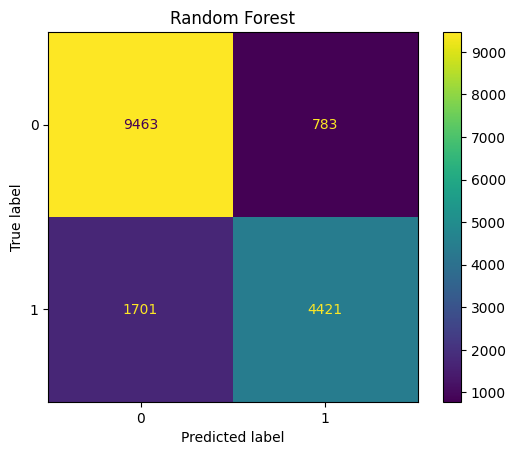

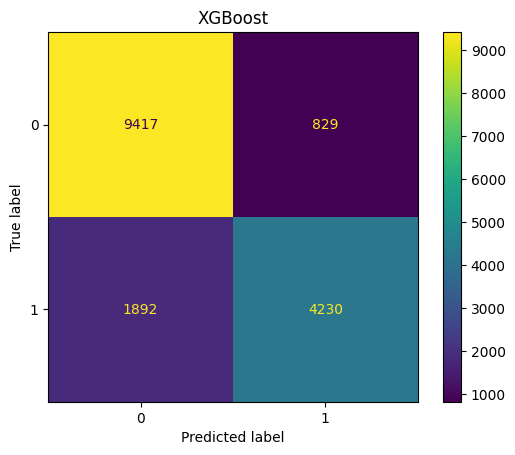

In [ ]:
models = [
    ("Logistic", log_model, X_test_scaled),
    ("Random Forest", rf_model, X_test),
    ("XGBoost", xgb_model, X_test)
]

for name, model, X_eval in models:
    ConfusionMatrixDisplay.from_estimator(model, X_eval, y_test)
    plt.title(name)
    plt.show()

#Tuning Model

In [79]:
value_counts = y.value_counts(normalize=True)
value_counts

,proportion
is_canceled,
0,0.625993
1,0.374007


In [74]:
LogisticRegression(class_weight='balanced')
RandomForestClassifier(class_weight='balanced')
scale_pos_weight = value_counts[0] / value_counts[1]

In [75]:
# Logistic Regression
param_log = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

log_search = RandomizedSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced'),
    param_log,
    n_iter=4,
    cv=3,
    scoring='roc_auc',
    random_state=42
)

log_search.fit(X_train_scaled, y_train)
best_log = log_search.best_estimator_

In [76]:
# Random Forest
param_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_rf,
    n_iter=10,
    cv=3,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

In [77]:
#XGBoost
xgb = XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=scale_pos_weight)
param_dist = {
    'n_estimators': [200, 300, 400],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

random_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    n_iter=10,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_xgb = random_search.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [82]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]

    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))

In [83]:
# Logistic (scaled)
evaluate_model("Logistic Tuned", best_log, X_test_scaled, y_test)

# RF
evaluate_model("RF Tuned", best_rf, X_test, y_test)

# XGB
evaluate_model("XGB Tuned", best_xgb, X_test, y_test)


===== Logistic Tuned =====
              precision    recall  f1-score   support

           0       0.84      0.81      0.82     10246
           1       0.70      0.74      0.72      6122

    accuracy                           0.78     16368
   macro avg       0.77      0.77      0.77     16368
weighted avg       0.79      0.78      0.78     16368

ROC-AUC: 0.861539236704543

===== RF Tuned =====
              precision    recall  f1-score   support

           0       0.86      0.89      0.88     10246
           1       0.81      0.76      0.78      6122

    accuracy                           0.84     16368
   macro avg       0.84      0.83      0.83     16368
weighted avg       0.84      0.84      0.84     16368

ROC-AUC: 0.9151516120616754

===== XGB Tuned =====
              precision    recall  f1-score   support

           0       0.86      0.86      0.86     10246
           1       0.76      0.77      0.77      6122

    accuracy                           0.83     16368


#Features Importance

In [84]:
import shap

# Konversi kolom boolean di X_train dan X_test ke integer
X_train_numeric = X_train.astype(float)
X_test_numeric = X_test.astype(float)

# Gunakan model XGBoost terbaik (setelah tuning)
explainer = shap.Explainer(best_xgb, X_train_numeric)

shap_values = explainer(X_test_numeric)

100%|===================| 16358/16368 [03:11<00:00]       

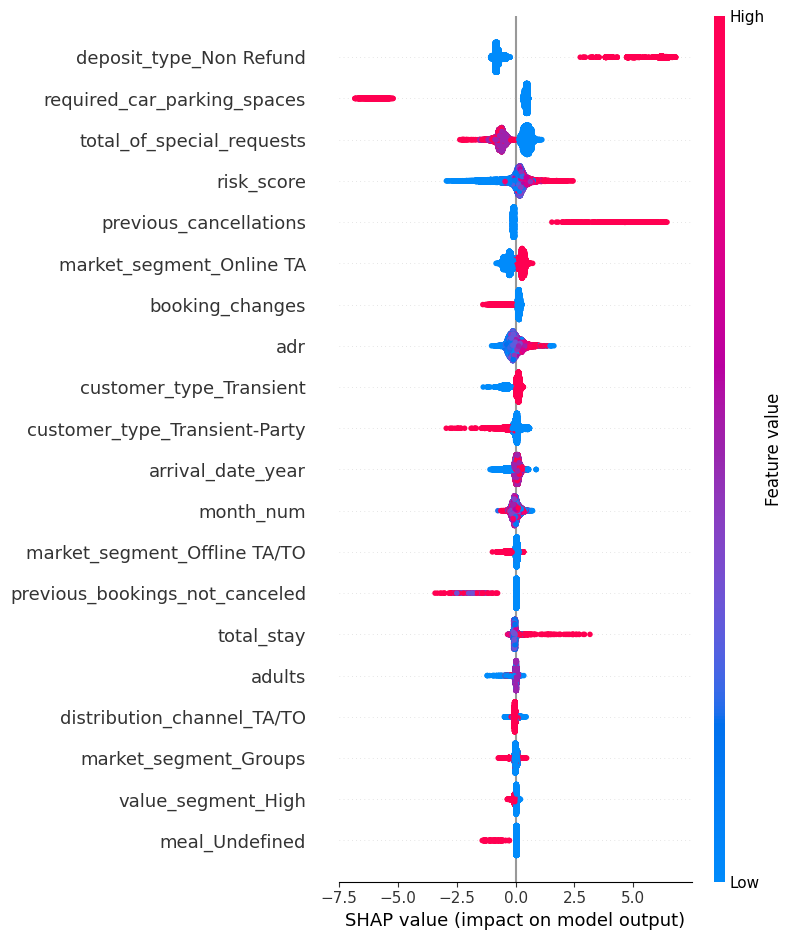

In [85]:
shap.summary_plot(shap_values, X_test)

##Interpretasi SHAP
Berdasarkan hasil analisis SHAP, fitur yang paling berpengaruh dalam memprediksi pembatalan booking adalah deposit_type_Non Refund, required_car_parking_spaces, total_of_special_requests, risk_score, dan previous_cancellations.

Fitur deposit_type_Non Refund memiliki pengaruh paling besar, di mana booking dengan tipe non-refundable cenderung memiliki kemungkinan pembatalan yang lebih rendah. Hal ini menunjukkan bahwa kebijakan deposit memainkan peran penting dalam mengurangi risiko pembatalan.

Fitur previous_cancellations dan risk_score menunjukkan bahwa pelanggan dengan riwayat pembatalan sebelumnya serta skor risiko yang tinggi memiliki kecenderungan lebih besar untuk melakukan pembatalan di masa mendatang.

Sementara itu, fitur seperti total_of_special_requests dan required_car_parking_spaces memiliki pengaruh negatif terhadap pembatalan, yang mengindikasikan bahwa pelanggan dengan kebutuhan khusus atau permintaan tambahan cenderung lebih serius dan berkomitmen terhadap booking mereka.

Dari sisi segmentasi, fitur seperti market_segment_Online TA dan customer_type_Transient juga memberikan kontribusi terhadap peningkatan kemungkinan pembatalan, yang menunjukkan bahwa pelanggan dari kanal online dan tipe transient memiliki perilaku yang lebih tidak stabil dibandingkan segmen lainnya.

Secara keseluruhan, model menunjukkan bahwa perilaku pembatalan dipengaruhi oleh kombinasi faktor kebijakan (deposit), perilaku historis pelanggan, serta karakteristik booking, bukan hanya satu faktor tunggal.

##Insight
Hasil ini menunjukkan bahwa strategi seperti penerapan kebijakan deposit yang lebih ketat, serta identifikasi pelanggan dengan riwayat pembatalan tinggi, dapat membantu mengurangi tingkat pembatalan dan meningkatkan pendapatan hotel.

#Setup Streamlit

In [89]:
import joblib

joblib.dump(best_xgb, 'model.pkl')
joblib.dump(X_encoded.columns, 'features.pkl')

['features.pkl']